# Assignment 2: Repository setup and the machine learning vocabulary

*Kira Wiesinger.*

*AI transparency: Google Gemini was used as a tool to support conceptual understanding. It was not used to generate code or generate written responses.*

This assignment has two pieces. Part 1 sets up the private GitHub repository you will submit every assignment to. Part 2 applies the Week 1 machine learning vocabulary to the Mauna Loa CO
 record: one short experiment and four written questions.

The data preprocessing exercises on tropical cyclone records that were originally here are now Assignment 3, since we did not finish that material in class.

Answer each numbered question in the empty cell below it.

# Part 1: Create your assignments repository

You will submit every assignment in this course by pushing to a private GitHub repository. Set it up now.

Create a directory called ml4climate2026 on your machine.

Add a README.md containing your name.

Initialize a git repository, and make your first commit.

Create a private repository on GitHub called ml4climate2026. Use exactly that name. Do not vary the spelling, capitalization, or punctuation.

Push your local repository to GitHub.

On GitHub, go to Settings -> Collaborators and add dmw2166.

Add this completed notebook to the repository, commit, and push.

Push new commits to this repository whenever you are ready to hand in an assignment, and submit the link to CourseWorks for gradebook purposes.

Paste the output of git log --oneline below, showing your commit history.

*aec9439 (HEAD -> main, origin/main) Made small revisions, resubmitted*

*f085577 Paste git log oneline output into assignment*

*78e079d Add completed assignment 2*

*d1d0f88 first commit*

# Part 2: Intro to ML

The Week 1 lecture notes lay out the vocabulary: the three learning paradigms, the eight-step workflow, and the strengths and weaknesses of data-driven methods. The questions in this part ask you to apply those ideas to the Mauna Loa CO
 record, the longest continuous direct measurement of atmospheric carbon dioxide anywhere in the world.

The cell below loads the record for you. If you did the optional coding review in Assignment 1 you have seen it before; if not, run it and look at the columns. average is the monthly mean concentration in ppm and decimal_date is the time of each value as a decimal year, which is the natural x variable for fitting.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# The Mauna Loa CO2 record, straight from NOAA. The file has about 40 lines of
# header comments before the data begins, which comment="#" skips.
url = "https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.csv"
co2 = pd.read_csv(url, comment="#")
co2 = co2.rename(columns={"decimal date": "decimal_date"})

# Build a proper datetime column (measurements are monthly means, dated mid-month).
co2["date"] = pd.to_datetime(dict(year=co2["year"], month=co2["month"], day=15))

# NOAA codes missing monthly means as -99.99.
co2 = co2[co2["average"] > 0].reset_index(drop=True)

co2

,year,month,decimal_date,average,deseasonalized,ndays,sdev,unc,date
0,1958,3,1958.2027,315.71,314.44,-1,-9.99,-0.99,1958-03-15
1,1958,4,1958.2877,317.45,315.16,-1,-9.99,-0.99,1958-04-15
2,1958,5,1958.3699,317.51,314.69,-1,-9.99,-0.99,1958-05-15
3,1958,6,1958.4548,317.27,315.15,-1,-9.99,-0.99,1958-06-15
4,1958,7,1958.5370,315.87,315.20,-1,-9.99,-0.99,1958-07-15
...,...,...,...,...,...,...,...,...,...
817,2026,4,2026.2917,431.12,428.61,23,1.16,0.46,2026-04-15
818,2026,5,2026.3750,432.34,429.06,19,0.64,0.28,2026-05-15
819,2026,6,2026.4583,431.43,428.99,19,0.27,0.12,2026-06-15
820,2026,7,2026.5417,429.13,428.78,21,0.61,0.26,2026-07-15


### 2. Before answering anything conceptual, run one experiment.

Fit a straight line to the record using only the data up to the end of 1999 (numpy.polyfit on decimal_date against average, degree 1). Then use that line to predict CO
 for 2000 onwards. Plot the observations for the whole record together with the extrapolated line, and report the prediction error in ppm for the most recent year in the dataset.

In [2]:
slope, intercept = np.polyfit(co2['decimal_date'], co2['average'], 1)
print(f'Slope:{slope}')
print(f'Intercept: {intercept}')

Slope:1.6698925434436027
Intercept: -2965.760262774343


In [3]:
co2_1999 = co2[co2['decimal_date'] < 2000]
slope_1999, intercept_1999 = np.polyfit(co2_1999['decimal_date'], co2_1999['average'], 1)

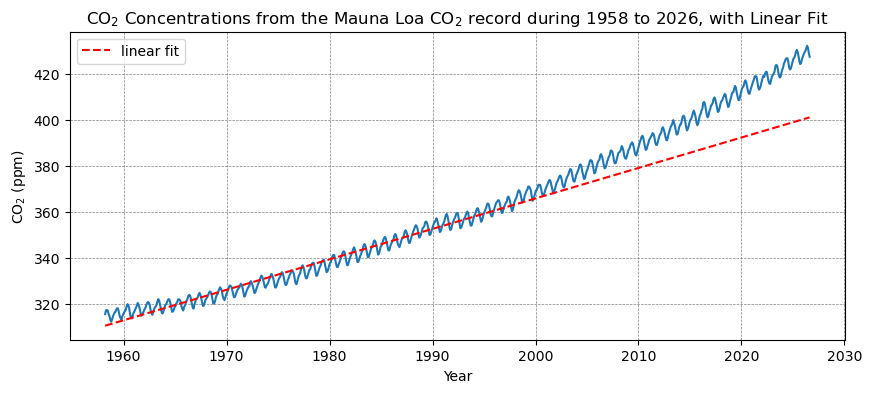

In [4]:
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(co2['decimal_date'], co2['average'])
ax.plot(co2['decimal_date'], slope_1999*co2['decimal_date'] + intercept_1999,
       'r--', label = 'linear fit')
ax.set_title('CO$_2$ Concentrations from the Mauna Loa CO$_2$ record during 1958 to 2026, with Linear Fit')
ax.set_xlabel('Year')
ax.set_ylabel('CO$_2$ (ppm)')
ax.legend()
ax.grid(True, linestyle='--', color='gray', linewidth=0.5)

In [5]:
actual_latest_conc = co2['average'].iloc[-1]
actual_latest_conc

427.55

In [6]:
latest_date = co2['decimal_date'].iloc[-1] 
latest_date

2026.625

In [7]:
predicted_latest_conc = (slope_1999 * latest_date) + intercept_1999
predicted_latest_conc

401.21910899202203

In [8]:
error = actual_latest_conc - predicted_latest_conc
print(f'Prediction error for the most recent year in the dataset ({np.floor(latest_date).astype(int)}): {round(error,2)} ppm')

Prediction error for the most recent year in the dataset (2026): 26.33 ppm


### 3. You have now fit a model that learned two parameters from data (slope and intercept) and made predictions without anyone programming the relationship explicitly. By the definition given in the lecture notes, is numpy.polyfit a machine learning algorithm? Justify your answer.



*Yes, numpy.polyfit is a machine learning algorithm because the computer is learning from experience (E) using the training data (in this case, CO2 concentration data from 1958 to 1999) to carry out the task (T) of predicting values (in this case, CO2 concentrations) for a given year. It uses a performance measure (P) of determining how accurately continuous values (of CO2 concentrations) are predicted, as measured by least squares. It is learning from experience E based on task T to determine if its performance on T, measured by P, improves with E. This aligns with Tom Mitchell's definition of machine learning.*

*It also aligns with Arthur Samuel's definition of machine learning because the computer learned to do a task using numpy.polyfit by running the least-squares algorithm on the data without being explicitly programmed to do it.*

### 4. The notes divide machine learning into supervised, unsupervised, and reinforcement learning. Consider two operations on this record:

(a) the straight-line fit of concentration against date (question 2)

(b) extracting the mean seasonal cycle by grouping the record by calendar month and averaging the departure of each month from the deseasonalized trend (the optional coding review in Assignment 1 does this; you do not need to have done it to answer)

Which paradigm, if any, does each belong to?

*(a) falls into supervised learning because the model is trained on labeled pairs of inputs, date and CO2 concentration, to learn a mapping function on historical data (1958-1999) that minimizes prediction error and applies it to a later time period (2000-2026). The CO2 concentration is the desired output.*

*(b) does not fall into any of the three paradigms because grouping by calendar month and taking averages is simply applying descriptive statistical formulas rather than learning from experience with respect to a task and a performance measure.*

### 5. Frame a genuine supervised learning problem using this dataset. You are not being asked to implement it. Your answer must specify, concretely:

- the input features and the label
- how you would split the data into training and test sets
- what loss function you would minimize
- what result would make you conclude the model had learned something real, as opposed to something you already knew

*I would predict the annual seasonal amplitude of atmospheric CO2 for a given year t, using 1958-2010 as the baseline and 2011 to 2026 as the predicted time period.*

*The seasonal amplitude is the difference between the peak of CO2 concentrations during the year, which occurs in the spring, and the lowest value of CO2 concentration in the year, which occurs in fall.*

*Equation: Seasonal amplitude of CO2 = change in CO2 = CO2 concentration peak - CO2 concentration trough, for a given year t.*

*Input features: previous year's seasonal amplitude and previous year's annual mean CO2 concentration.*

*Label feature: Seasonal amplitude of CO2 for year t.* 

*Training set: Annual observations from 1958 to 2010.*

*Test set: Annual observations from 2011 to 2026.*

*Loss function to minimize: Mean Squared Error calculated between the predicted seasonal amplitude and the true seasonal amplitude.*

*The result that would make me conclude the model learned something real is if Mean Squared Error of the test set (2011-2026) is statistically significantly lower than the following:*

*1. A benchmark predicting the average amplitude from the 1958-2010 training period for every year in the test period, 2011-2026. This is called the climatological mean baseline.*

*2. A different benchmark which makes the assumption that the following year's amplitude will be equal to the prior year's amplitude. This is called naive forecasting or persistence forecasting.*

*Having a statistically significantly lower MSE than the two benchmarks above indicates that the model is using the prior CO2 concentration information and amplitude trends to predict interannual changes in the seasonal carbon cycle, which demonstrates that it learned something that I did not already know.*

### 6. The notes state that machine learning models “typically do a poor job of extrapolating to unseen data regimes.” Your experiment in question 2 is a small demonstration of exactly that.

### Suppose you needed a projection of atmospheric CO2 for the year 2100. Would a flexible machine learning model (a neural network, say) trained on this same record do better or worse than your straight line? Explain your reasoning, and then explain what a physics-based carbon cycle model has access to that neither of them does.

*A flexible machine learning model trained on the same record would do worse than a straight line because machine learning models do not do well in extrapolating to unseen data regimes, such as time periods far into the future. 2100 is many decades from now, so a machine learning model with a training dataset of 1958 to 1999 would do a poor job of extrapolating atmospheric CO2 concentrations to 2100. A more flexible machine learning model, like a neural network, could create non-linear predictions that could be inconsistent when working outside of the range of the training data. In contrast, a straight line avoids any non-linear divergence, which is more useful for extrapolating atmospheric CO2 concentrations over a long time period, like the 100-year period from 2000 to 2100.*

*A physics-based carbon cycle model incorporates physical laws and processes of the atmosphere, ocean, and land, and may also include various emissions scenarios, while machine learning models and straight lines do not have access to these physical processes.*